In [ ]:
# load parquet
import pandas as pd
import pyarrow.parquet as pq

import hydra
from hydra.core.config_store import ConfigStore
from hydra.core.hydra_config import HydraConfig
from loguru import logger
from evaluate.loading import load as load_metric
from utils.config_schema import ConfigSchema, ModelConfigSchema

/opt/miniconda3/envs/master/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [69]:
from pathlib import Path
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# metrics may already be dicts or strings that look like dicts
def to_dict_safe(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    return ast.literal_eval(x if isinstance(x, str) else str(x))

def load_latest_detailed_results_parsed(model, dataset, subset, split, base="../experiments/evaluate_model"):
    """
    Returns (df, parquet_path)

    df columns: id, prediction, label, clip_length, CER, WER
    """
    root = Path(base) / f"{model}_{dataset}_{subset}_{split}"

    # find every detailed_results.parquet under root, ignore .hydra
    files = [p for p in root.rglob("detailed_results.parquet") if ".hydra" not in p.parts]
    if not files:
        raise FileNotFoundError(f"No detailed_results.parquet under {root}")

    newest = max(files, key=lambda p: p.stat().st_mtime)

    # read with pyarrow to avoid partial row group reads
    df = pd.read_parquet(newest, engine="pyarrow")

    m = df["metrics"].apply(to_dict_safe)
    metrics_df = pd.json_normalize(m)

    # attach CER and WER, drop original metrics
    df = pd.concat([df.drop(columns=["metrics"]), metrics_df], axis=1).rename(
        columns={"cer": "CER", "wer": "WER"}
    )

    return df

def compute_avg_metrics(df):
    # compute average CER and WER
    metrics = {
        "CER": df["CER"].mean(),
        "WER": df["WER"].mean(),
    }

    # compute median CER and WER
    metrics["CER_median"] = df["CER"].median()
    metrics["WER_median"] = df["WER"].median()

    # compute stddev CER and WER
    metrics["CER_std"] = df["CER"].std()
    metrics["WER_std"] = df["WER"].std()

    # compute average clip length
    metrics["avg_clip_length"] = df["clip_length"].mean()

    # do the same for all clips shorther than 10 seconds
    short_df = df[df["clip_length"] <= 10.0]
    metrics["CER_short"] = short_df["CER"].mean()
    metrics["WER_short"] = short_df["WER"].mean()
    metrics["CER_short_median"] = short_df["CER"].median()
    metrics["WER_short_median"] = short_df["WER"].median()
    metrics["CER_short_std"] = short_df["CER"].std()
    metrics["WER_short_std"] = short_df["WER"].std()
    metrics["avg_clip_length_short"] = short_df["clip_length"].mean()
    return metrics

def plot_metrics(df):

    sns.set(style="whitegrid")

    # plot distribution of CER and WER and compute correlation
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(df["CER"], bins=30, kde=True, ax=axes[0])
    axes[0].set_title("Distribution of CER")
    axes[0].set_xlabel("CER")
    axes[0].set_ylabel("Density")

    sns.histplot(df["WER"], bins=30, kde=True, ax=axes[1])
    axes[1].set_title("Distribution of WER")
    axes[1].set_xlabel("WER")
    axes[1].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

    # plot CER and WER vs clip length
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.scatterplot(x="clip_length", y="CER", data=df, ax=axes[0])
    axes[0].set_title("CER vs Clip Length")
    axes[0].set_xlabel("Clip Length (s)")
    axes[0].set_ylabel("CER")
    sns.scatterplot(x="clip_length", y="WER", data=df, ax=axes[1])
    axes[1].set_title("WER vs Clip Length")
    axes[1].set_xlabel("Clip Length (s)")
    axes[1].set_ylabel("WER")
    plt.tight_layout()
    plt.show()

    # compute correlation between CER, WER and clip length
    corr = df[["CER", "WER", "clip_length"]].corr()
    print("Correlation matrix:")
    print(corr)

In [72]:
df = load_latest_detailed_results_parsed("hviske-v2", "fleurs", "da_dk", "test")
print("Loaded rows:", len(df))
df.head()

Loaded rows: 930


,id,prediction,label,clip_length,CER,WER
0,1908,dette er en vigtig måde at skelne mellem nogle...,dette er en vigtig måde at skelne mellem nogle...,5.10,0.000000,0.000000
1,1842,fordi dinosaurfjerene ikke har et veludviklet ...,fordi dinosaurfjerene ikke har et veludviklet ...,18.24,0.056225,0.114286
2,1876,nordmarinanernes beredskabskontor meddelte at ...,nordmarianernes beredskabskontor meddelte at d...,6.84,0.011111,0.083333
3,1856,finland er et fantastisk rejsemål for sejlere ...,finland er et fantastisk rejsemål for sejlere ...,11.34,0.007752,0.043478
4,1836,folk har kendt til de grundlæggende kemiske gr...,folk har kendt til de grundlæggende kemiske gr...,22.44,0.013889,0.027027


Average metrics:
  CER: 0.0447
  WER: 0.1122
  CER_median: 0.0287
  WER_median: 0.0870
  CER_std: 0.0567
  WER_std: 0.1118
  avg_clip_length: 11.3754
  CER_short: 0.0467
  WER_short: 0.1179
  CER_short_median: 0.0288
  WER_short_median: 0.0800
  CER_short_std: 0.0645
  WER_short_std: 0.1266
  avg_clip_length_short: 7.7907


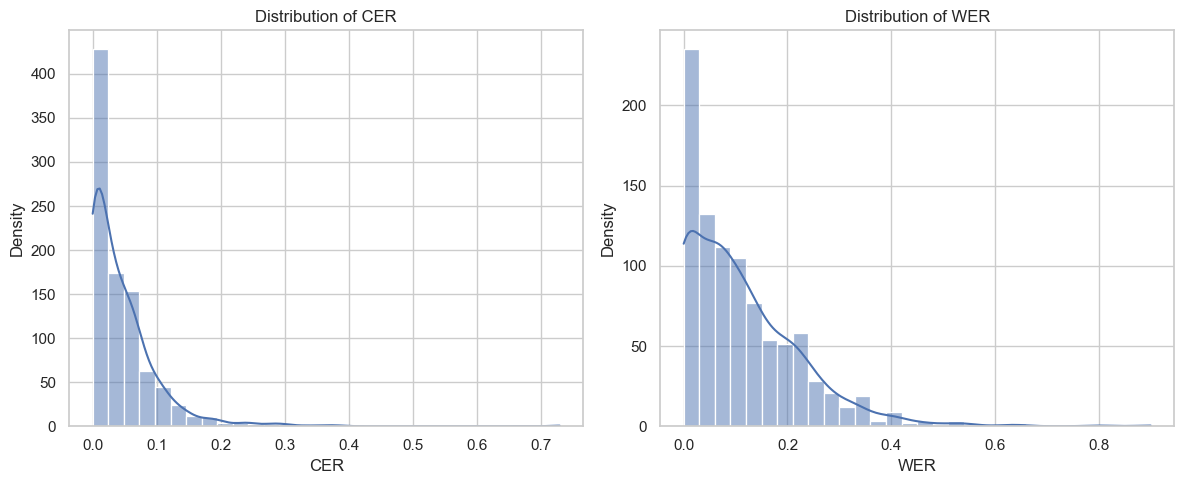

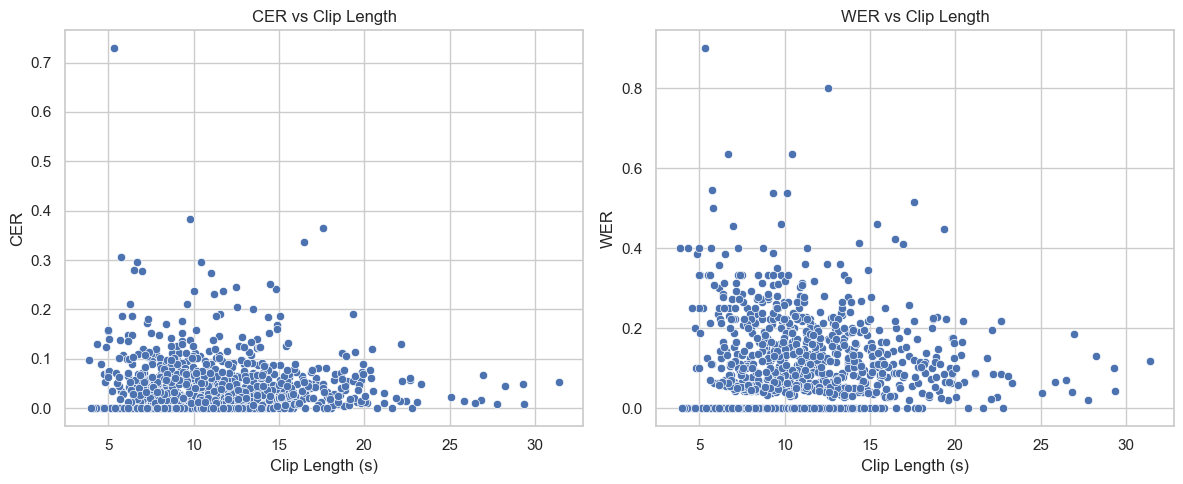

Correlation matrix:
                  CER       WER  clip_length
CER          1.000000  0.841182    -0.037540
WER          0.841182  1.000000    -0.058374
clip_length -0.037540 -0.058374     1.000000


In [73]:
metrics = compute_avg_metrics(df)
print("Average metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

plot_metrics(df)

In [1]:
from carbontracker import parser

In [ ]:
import re

logs = parser.parse_all_logs(log_dir=base)

pattern = re.compile(
    r"eval-(?P<model>[^-]+)-(?P<dataset_name>[^-]+)-(?P<dataset_subset>[^-]+)-(?P<dataset_split>[^_]+)_"
)

model = "hviske-v2"
dataset_name = "fleurs"
dataset_subset = "da_dk"
dataset_split = "test"

target_prefix = f"eval-{model}-{dataset_name}-{dataset_subset}-{dataset_split}"

matching_logs = [
    log for log in logs
    if re.search(pattern, log['output_filename'])
    and target_prefix in log['output_filename']
]

if matching_logs:
    selected_log = matching_logs[-1] # get the latest log
    print("Matched log:", selected_log['output_filename'])
else:
    print("No match found")

In [ ]:
MODELS = [
    "whisper-large-v3",
    "whisper-large-v3-turbo",
    "roest-wav2vec2-315m-v2",
    "roest-wav2vec2-1B-v2",
    "roest-wav2vec2-2B-v2",
    "hviske-v3-conversation",
    "hviske-v2",
    "roest-whisper-large-v1",
    "seamless-m4t-v2-large",
    "parakeet-tdt-0.6b-v3",
    "canary-1b-v2",
]

DATASETS = [
    "coral-v2",
    "fleurs",
]

SUBSETS = {
    "coral-v2": "read_aloud",
    "fleurs": "da_dk",
}

SPLITS = {
    "coral-v2": "test",
    "fleurs": "test",
}



In [6]:
EVALUATION_COMBINATIONS

[{'model': 'whisper-large-v3',
  'dataset_name': 'coral-v2',
  'dataset_subset': 'read_aloud',
  'dataset_split': 'test'},
 {'model': 'whisper-large-v3',
  'dataset_name': 'fleurs',
  'dataset_subset': 'da_dk',
  'dataset_split': 'test'},
 {'model': 'whisper-large-v3-turbo',
  'dataset_name': 'coral-v2',
  'dataset_subset': 'read_aloud',
  'dataset_split': 'test'},
 {'model': 'whisper-large-v3-turbo',
  'dataset_name': 'fleurs',
  'dataset_subset': 'da_dk',
  'dataset_split': 'test'},
 {'model': 'roest-wav2vec2-315m-v2',
  'dataset_name': 'coral-v2',
  'dataset_subset': 'read_aloud',
  'dataset_split': 'test'},
 {'model': 'roest-wav2vec2-315m-v2',
  'dataset_name': 'fleurs',
  'dataset_subset': 'da_dk',
  'dataset_split': 'test'},
 {'model': 'roest-wav2vec2-1B-v2',
  'dataset_name': 'coral-v2',
  'dataset_subset': 'read_aloud',
  'dataset_split': 'test'},
 {'model': 'roest-wav2vec2-1B-v2',
  'dataset_name': 'fleurs',
  'dataset_subset': 'da_dk',
  'dataset_split': 'test'},
 {'model': '